Environment Set-Up

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install packages
!pip install pyampute
!pip install imbalanced-learn
!pip install dataframe_image
import dataframe_image as dfi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.1/180.1 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 15.4 MB/s eta 0:00:00


In [3]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

# Preprocessing Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Modeling Libraries
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay, roc_curve, auc)

# Miscellaneous



print("Libraries successfully imported")

Libraries successfully imported


In [4]:
# Accessibility - to be applied to all plots
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colorblind safe palette
# Use Wong Color Blind Pallet Hex Codes
sns.set_palette("colorblind")

print("Libraries loaded and styling applied successfully")

Libraries loaded and styling applied successfully


In [5]:
# Load saved Preprocessing Data

# Original clean sets
X_train_encoded = pd.read_csv('/content/drive/MyDrive/X_train_encoded.csv')
X_test_encoded = pd.read_csv('/content/drive/MyDrive/X_test_encoded.csv')
y_train = pd.read_csv('/content/drive/MyDrive/y_train.csv')
y_test = pd.read_csv('/content/drive/MyDrive/y_test.csv')

# SMOTE sets
X_train_smote = pd.read_csv('/content/drive/MyDrive/X_train_smote.csv')
y_train_smote = pd.read_csv('/content/drive/MyDrive/y_train_smote.csv')

print(f"Dataset loaded:", X_train_encoded.shape)
print(f"Dataset loaded:", X_test_encoded.shape)
print(f"Dataset loaded:", X_train_smote.shape)
print(f"y_train loaded:", y_train.shape)
print(f"y_test loaded:", y_test.shape)

Dataset loaded: (213, 16)
Dataset loaded: (84, 16)
Dataset loaded: (230, 16)
y_train loaded: (213, 1)
y_test loaded: (84, 1)


In [6]:
print(y_train.columns.tolist())
print(y_test.columns.tolist())

['target']
['target']


In [7]:
# Change Target to 1D Array

# Flatten target variables to 1D arrays
y_train = y_train['target']
y_test = y_test['target']
y_train_smote = y_train_smote['target']

print("Target variables confirmed:")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print(f"\ny_train distribution:")
print(y_train.value_counts())

Target variables confirmed:
y_train shape: (213,)
y_test shape: (84,)
y_train_smote shape: (230,)

y_train distribution:
target
0    115
1     98
Name: count, dtype: int64


#Logistic Regression

Check on Assumptions

Original Box - Tidwell test left in for reference and commented out. After updating the age column to binned category and saving training sets, this initial test did not have the age column initially tested.

In [8]:
# Box Tidwell Test
# Linearity of log-odds
# If interaction term is p < 0.05 linearity assumption is violated

#import statsmodels.api as sm

# Continuous variables to test
#continuous_cols = ['age', 'trestbps', 'thalach', 'chol_boxcox']

# Create copy of training data
#bt_train_encoded = X_train_encoded[continuous_cols].copy()

# Create interaction terms
#for col in continuous_cols:
   # bt_train_encoded[f'{col}_log'] = bt_train_encoded[col] * np.log(
        #np.abs(bt_train_encoded[col]) + 1e-10) # avoid log 0 error

# Add constant for intercept
#bt_train_encoded = sm.add_constant(bt_train_encoded) # adds intercept column

# Fit logistic regression with only interaction terms
#bt_model = sm.Logit(y_train, bt_train_encoded)
#bt_results = bt_model.fit(disp = 0)

# Print summary
#print(bt_results.summary())

In [9]:
# Address Log of Odds Assumption Violation
# Age Binning Using Scaled Thresholds
# Original age was standardized in preprocessing
# Scaled thresholds calculated from training mean (54.44) and std (9.04)
# Age < 45 = (45-54.44)/9.04 = -1.04 (Young)
# Age 45-60 = -1.04 to 0.62 (Middle)
# Age > 60 = (60-54.44)/9.04 = 0.62 (Older)


# Training set
#X_train_encoded['age_binned'] = pd.cut( # divide variables into bins
   # X_train_encoded['age'],
    #bins=[-np.inf, -1.04, 0.62, np.inf], # define bin boundaries
    #labels=[0, 1, 2]
#).astype(int)

# Test set
#X_test_encoded['age_binned'] = pd.cut(
   # X_test_encoded['age'],
    #bins=[-np.inf, -1.04, 0.62, np.inf],
    #labels=[0, 1, 2]
#).astype(int)

# SMOTE set
#X_train_smote['age_binned'] = pd.cut(
   # X_train_smote['age'],
    #bins=[-np.inf, -1.04, 0.62, np.inf],
    #labels=[0, 1, 2]
#).astype(int)

# Drop scaled age from all three sets
#X_train_encoded = X_train_encoded.drop(columns=['age'])
#X_test_encoded = X_test_encoded.drop(columns=['age'])
#X_train_smote = X_train_smote.drop(columns=['age'])

# Confirm
#print("Age binning complete:")
#print(f"X_train_encoded: {X_train_encoded.shape}")
#print(f"X_test_encoded: {X_test_encoded.shape}")
#print(f"X_train_smote: {X_train_smote.shape}")
#print(f"\nAge group distribution - Training:")
#print(X_train_encoded['age_binned'].value_counts().sort_index())
#print("0=Young(<45), 1=Middle(45-60), 2=Older(>60)")



In [11]:
# Box Tidwell Re-Check

# Box Tidwell Test
# Linearity of log-odds
# If interaction term is p < 0.05 linearity assumption is violated

import statsmodels.api as sm

# Continuous variables to test
continuous_new = ['trestbps', 'thalach', 'chol_boxcox'] #age no categoricsl and exempt from BT test

# Create copy of training data
bt_new = X_train_encoded[continuous_new].copy()

# Create interaction terms
for col in continuous_new:
    bt_new[f'{col}_log'] = bt_new[col] * np.log(
        np.abs(bt_new[col]) + 1e-10) # avoid log 0 error

# Add constant for intercept
bt_new = sm.add_constant(bt_new) # adds intercept column

# Fit logistic regression with only interaction terms
bt_model_new = sm.Logit(y_train, bt_new)
bt_results_new = bt_model_new.fit(disp = 0)

# Print summary
print(bt_results_new.summary())

                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  213
Model:                          Logit   Df Residuals:                      206
Method:                           MLE   Df Model:                            6
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.1464
Time:                        15:11:32   Log-Likelihood:                -125.45
converged:                       True   LL-Null:                       -146.96
Covariance Type:            nonrobust   LLR p-value:                 1.151e-07
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.1949      0.157     -1.241      0.215      -0.503       0.113
trestbps            0.0406      0.193      0.210      0.833      -0.338       0.419
thalach            -0.9470      

In [12]:
X_train_encoded.head()

,sex,trestbps,fbs,thalach,exang,ca,restecg_1,restecg_2,thal_6.0,thal_7.0,cp_2,cp_3,cp_4,chol_boxcox,st_severity,age_binned
0,1,0.208054,0,-0.845314,0,0.0,False,False,True,False,True,False,False,-0.884398,0,0
1,1,1.093186,1,0.293967,0,0.0,False,False,False,False,False,True,False,-0.662438,1,1
2,1,-0.677077,1,1.980102,0,0.0,False,False,False,True,False,True,False,-0.046478,0,0
3,1,-1.267165,0,-1.665596,1,0.0,False,True,False,True,False,False,True,-1.927178,3,0
4,0,1.683274,0,0.521823,0,2.0,False,False,False,False,True,False,False,1.024418,1,2


Create Baseline Model

In [13]:
# L2 Regularization Default
# Address overfitting concerns

# Initialize model
# C=1.0 is default regularization strength

lr_model = LogisticRegression(
    C=1.0,
    penalty='l2', # address overfitting on small dataset
    random_state=42,
    max_iter=1000,
    class_weight=None  # standard version first, CSL version later
)

# Fit on training set
lr_model.fit(X_train_encoded, y_train)

print("Logistic Regression model fitted successfully")
print(f"Number of features: {X_train_encoded.shape[1]}")
print(f"Classes: {lr_model.classes_}")

Logistic Regression model fitted successfully
Number of features: 16
Classes: [0 1]


In [14]:
# Stratified K-Fold Cross Validation

# Define stratified k-fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'specificity': 'recall_macro'
}

# Run cross validation
cv_results = cross_validate(
    lr_model,
    X_train_encoded,
    y_train,
    cv=skf,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("Logistic Regression - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results[f'train_{metric}'].mean()
    test_mean = cv_results[f'test_{metric}'].mean()
    test_std = cv_results[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

Logistic Regression - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.852        0.808      0.089
precision                   0.870        0.824      0.101
recall                      0.798        0.744      0.154
f1                          0.833        0.775      0.115
roc_auc                     0.926        0.887      0.066

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [15]:
# Test data

# Final evaluation using X_test_encoded
# Test set untouched during training and cross-validation


# Generate predictions
y_pred = lr_model.predict(X_test_encoded)
y_pred_proba = lr_model.predict_proba(X_test_encoded)[:, 1]

# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# Calculate specificity manually
specificity = tn / (tn + fp)

# Print results
print("Logistic Regression - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy:.3f}")
print(f"Precision:   {precision:.3f}")
print(f"Recall:      {recall:.3f}  (Sensitivity)")
print(f"Specificity: {specificity:.3f}")
print(f"F1:          {f1:.3f}")
print(f"ROC-AUC:     {roc_auc:.3f}")
print(f"\nConfusion Matrix:")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"True Positives:  {tp}")
print(f"False Negatives: {fn}")
print(f"\nClinical interpretation:")
print(f"Missed CVD cases (FN): {fn}")
print(f"False alarms (FP): {fp}")

Logistic Regression - Test Set Results
Accuracy:    0.833
Precision:   0.879
Recall:      0.744  (Sensitivity)
Specificity: 0.911
F1:          0.806
ROC-AUC:     0.932

Confusion Matrix:
True Negatives:  41
False Positives: 4
True Positives:  29
False Negatives: 10

Clinical interpretation:
Missed CVD cases (FN): 10
False alarms (FP): 4


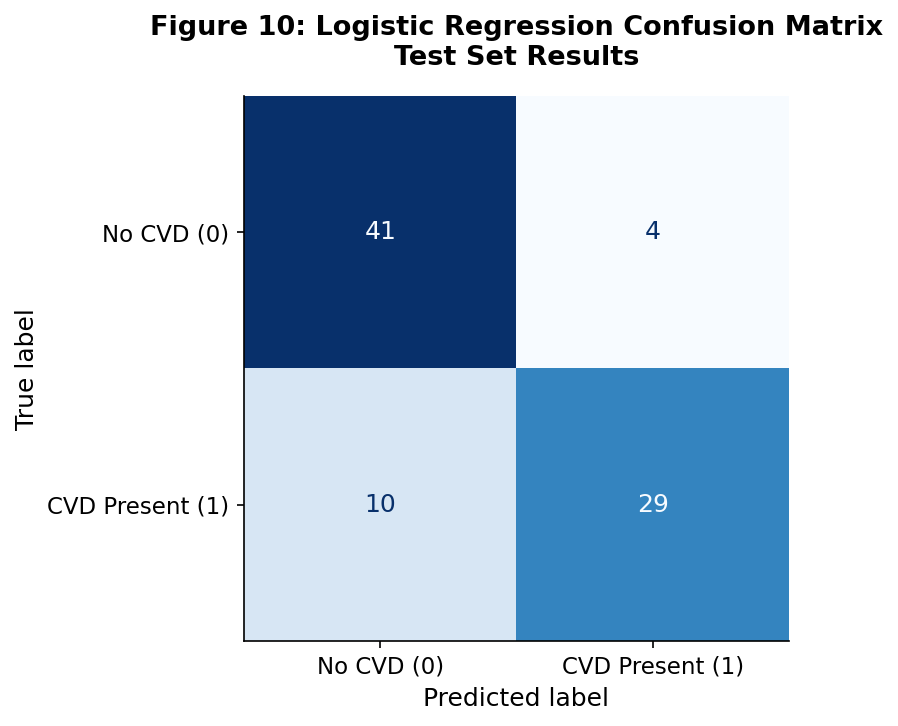

Figure 10 saved


In [16]:
# Confusion Matrix Visual - LR Baseline


fig, ax = plt.subplots(figsize=(7, 5))

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No CVD (0)', 'CVD Present (1)']) #readability

disp.plot(ax=ax, colorbar=False,
          cmap='Blues')

ax.set_title('Figure 10: Logistic Regression Confusion Matrix\nTest Set Results',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('figure10_confusion_matrix.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 10 saved")

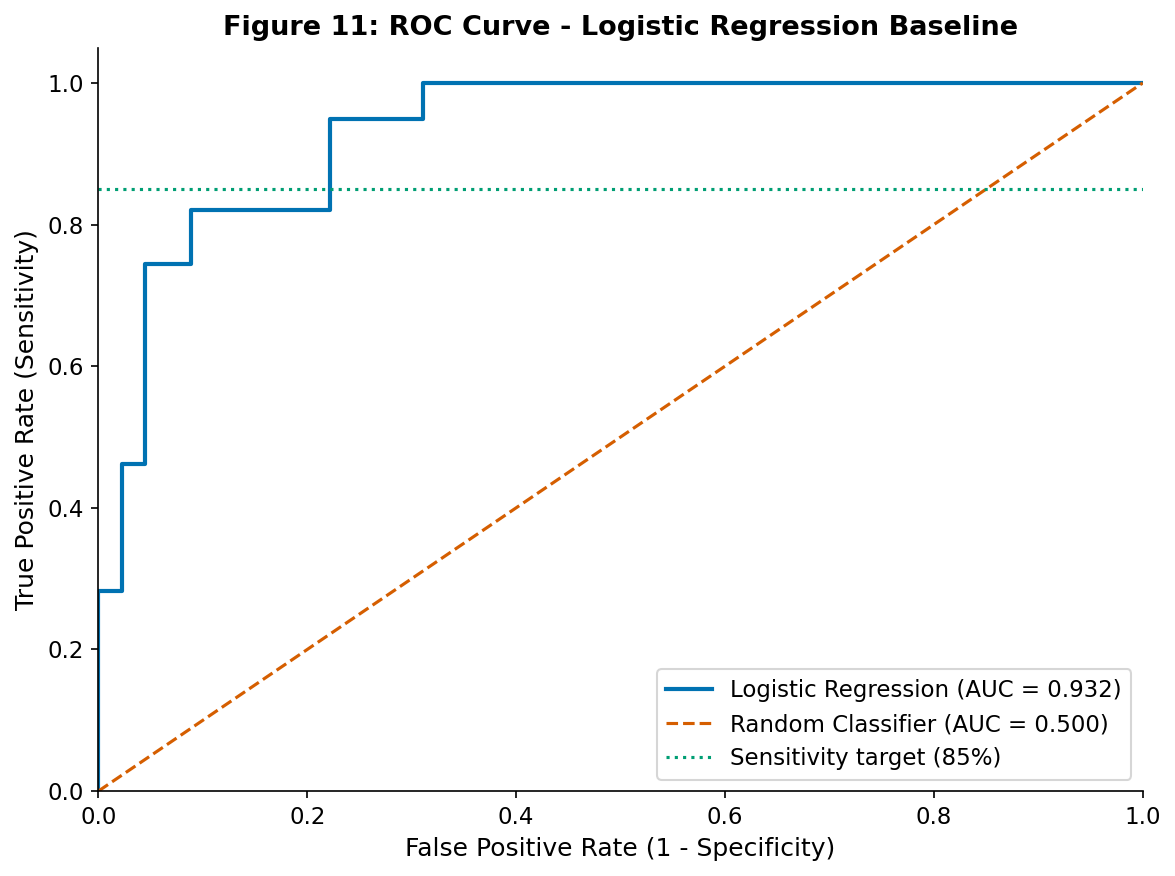

Figure 11 saved


In [17]:
# ROC - AUC Curve

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))

# Plot ROC curve
ax.plot(fpr, tpr, color='#0072B2', linewidth=2,
        label=f'Logistic Regression (AUC = {roc_auc:.3f})')

# Plot random classifier baseline
ax.plot([0, 1], [0, 1], color='#D55E00',
        linestyle='--', linewidth=1.5,
        label='Random Classifier (AUC = 0.500)')

# Add clinical target markers
ax.axhline(y=0.85, color='#009E73',
           linestyle=':', linewidth=1.5,
           label='Sensitivity target (85%)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Figure 11: ROC Curve - Logistic Regression Baseline',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('figure11_roc_curve.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 11 saved")

In [18]:
# Logistic Regression Coefficients
# Show feature importance and direction of relationship

# Postive = increases CVD probality
# Negative = decrease CVD probality

# Get coefficients
coef_df = pd.DataFrame({
    'Feature': X_train_encoded.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Logistic Regression Coefficients:")
print(coef_df.round(3).to_string(index=False))

Logistic Regression Coefficients:
    Feature  Coefficient
   thal_7.0        1.463
       cp_4        1.123
        sex        1.018
         ca        0.822
  restecg_2        0.679
      exang        0.657
st_severity        0.410
chol_boxcox        0.353
   trestbps        0.257
  restecg_1        0.150
   thal_6.0        0.109
 age_binned        0.070
       cp_2        0.003
        fbs       -0.276
    thalach       -0.360
       cp_3       -0.689


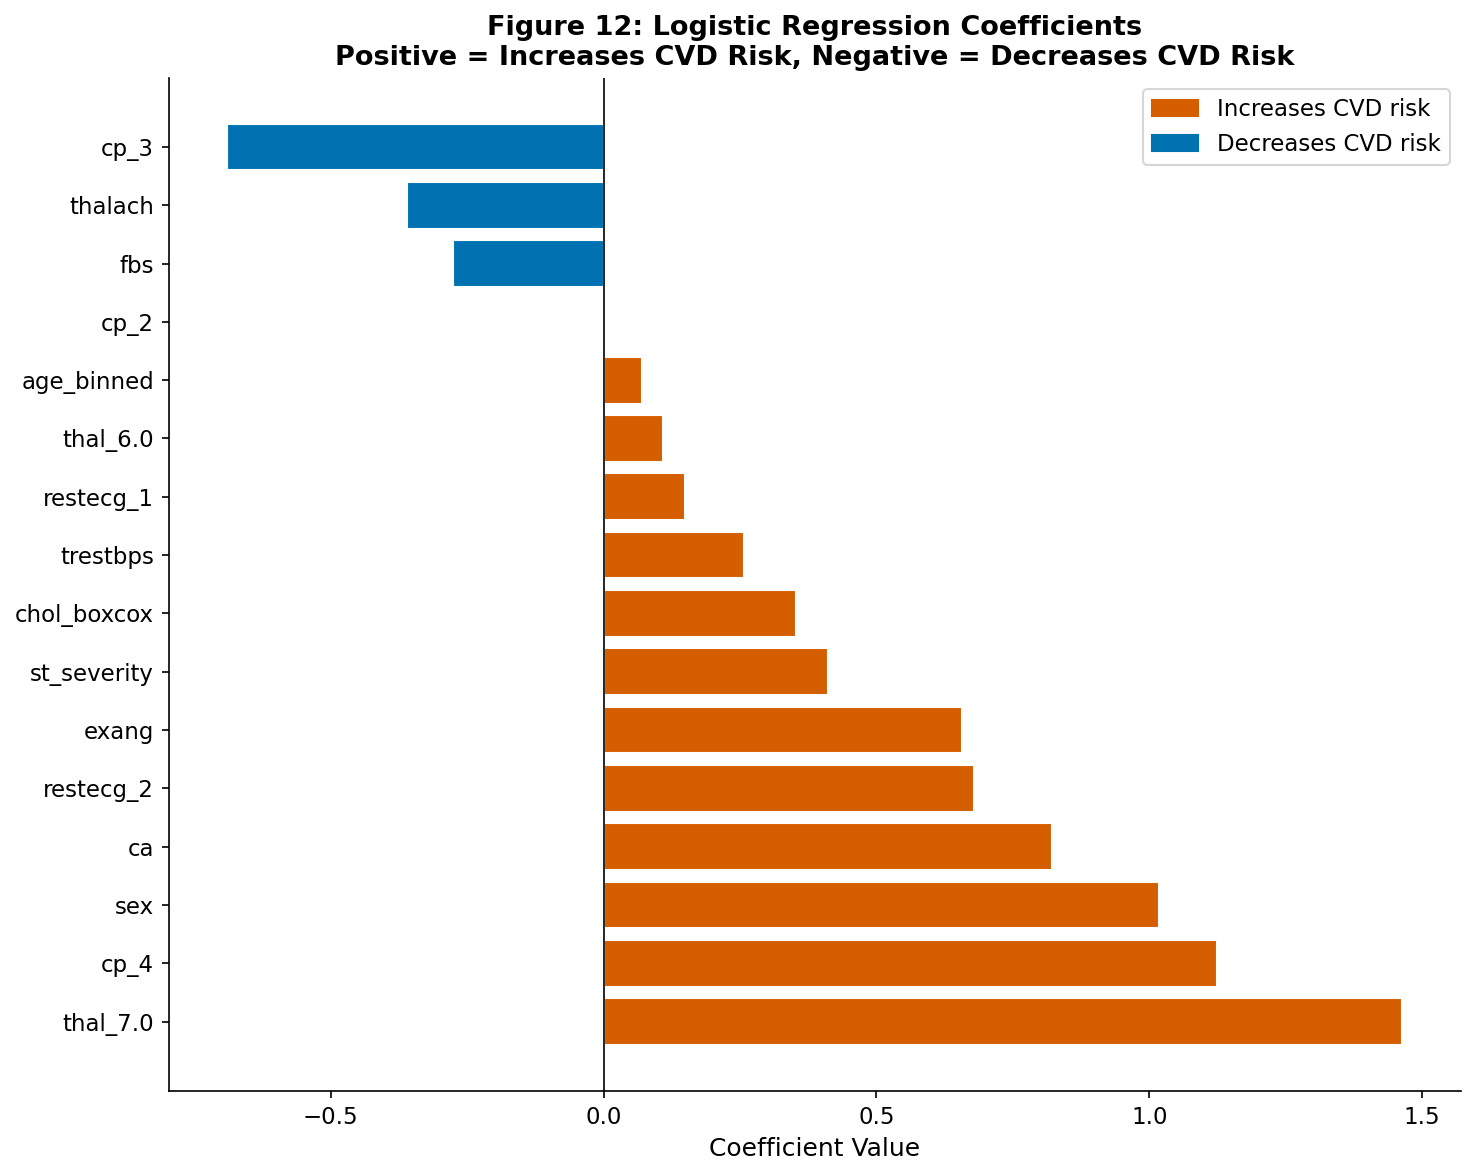

Figure 12 saved


In [19]:
# Visual Coefficient

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#D55E00' if c > 0 else '#0072B2'
          for c in coef_df['Coefficient']]

ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colors, edgecolor='white')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_title('Figure 12: Logistic Regression Coefficients\nPositive = Increases CVD Risk, Negative = Decreases CVD Risk',
             fontsize=13, fontweight='bold')

# Add legend
pos_patch = mpatches.Patch(color='#D55E00', label='Increases CVD risk')
neg_patch = mpatches.Patch(color='#0072B2', label='Decreases CVD risk')
ax.legend(handles=[pos_patch, neg_patch], fontsize=11)

plt.tight_layout()
plt.savefig('figure12_coefficients.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 12 saved")

LR - Baseline - SMOTE

In [20]:
# LR Training Set - SMOTE

# Performance Comparison
# SMOTE set balanced at 50/50 class distribution

# Train model on SMOTE set
lr_smote = LogisticRegression(
    C=1.0,
    penalty='l2',
    random_state=42,
    max_iter=1000,
    class_weight=None
)

# Fit on training set
lr_smote.fit(X_train_smote, y_train_smote)

print("Logistic Regression - SMOTE model fitted successfully")
print(f"Number of features: {X_train_smote.shape[1]}")
print(f"Classes: {lr_smote.classes_}")

Logistic Regression - SMOTE model fitted successfully
Number of features: 16
Classes: [0 1]


In [21]:
# Stratified k-fold SMOTE

# Define fresh StratifiedKFold for SMOTE set
skf_smote = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc'
    }

# Run cross validation on SMOTE training set
cv_results_smote = cross_validate(
    lr_smote,
    X_train_smote,
    y_train_smote,
    cv=skf_smote,
    scoring=scoring,
    return_train_score=True
)

# Print comparison
print("Cross Validation Comparison - Standard vs SMOTE")
print("=" * 65)
print(f"{'Metric':<20} {'Std Train':>10} {'Std Test':>10} {'SMOTE Train':>12} {'SMOTE Test':>12}")
print("-" * 65)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    std_train = cv_results[f'train_{metric}'].mean()
    std_test = cv_results[f'test_{metric}'].mean()
    smt_train = cv_results_smote[f'train_{metric}'].mean()
    smt_test = cv_results_smote[f'test_{metric}'].mean()
    print(f"{metric:<20} {std_train:>10.3f} {std_test:>10.3f} {smt_train:>12.3f} {smt_test:>12.3f}")

print("\nNote: CV performed on respective training sets")
print("Overfitting check: compare train vs test within each model")

Cross Validation Comparison - Standard vs SMOTE
Metric                Std Train   Std Test  SMOTE Train   SMOTE Test
-----------------------------------------------------------------
accuracy                  0.852      0.808        0.863        0.848
precision                 0.870      0.824        0.886        0.874
recall                    0.798      0.744        0.834        0.827
f1                        0.833      0.775        0.859        0.846
roc_auc                   0.926      0.887        0.933        0.902

Note: CV performed on respective training sets
Overfitting check: compare train vs test within each model


In [22]:
# SMOTE Test Set evaluation

# Generate predictions on test set
y_pred_smote = lr_smote.predict(X_test_encoded)
y_pred_proba_smote = lr_smote.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
tn_s, fp_s, fn_s, tp_s = cm_smote.ravel()

# Calculate metrics
specificity_smote = tn_s / (tn_s + fp_s)

print("SMOTE Model - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_score(y_test, y_pred_smote):.3f}")
print(f"Precision:   {precision_score(y_test, y_pred_smote):.3f}")
print(f"Recall:      {recall_score(y_test, y_pred_smote):.3f}  (Sensitivity)")
print(f"Specificity: {specificity_smote:.3f}")
print(f"F1:          {f1_score(y_test, y_pred_smote):.3f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_pred_proba_smote):.3f}")
print(f"\nFalse Negatives: {fn_s}")
print(f"False Positives: {fp_s}")

SMOTE Model - Test Set Results
Accuracy:    0.857
Precision:   0.886
Recall:      0.795  (Sensitivity)
Specificity: 0.911
F1:          0.838
ROC-AUC:     0.936

False Negatives: 8
False Positives: 4


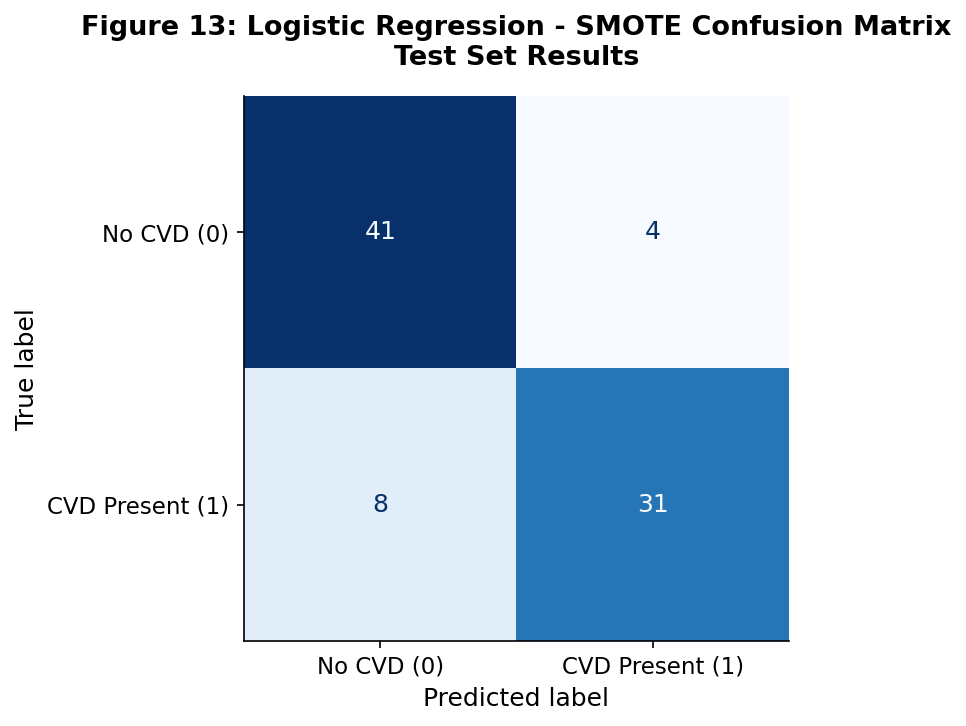

Figure 13 saved


In [23]:
# SMOTE Model - Confusion Matrix

fig, ax = plt.subplots(figsize=(7, 5))

# Display confusion matrix
disp_smote = ConfusionMatrixDisplay(
    confusion_matrix=cm_smote,
    display_labels=['No CVD (0)', 'CVD Present (1)']) #readability

disp_smote.plot(ax=ax, colorbar=False,
          cmap='Blues')

ax.set_title('Figure 13: Logistic Regression - SMOTE Confusion Matrix\nTest Set Results',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('figure13_confusion_smote.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 13 saved")

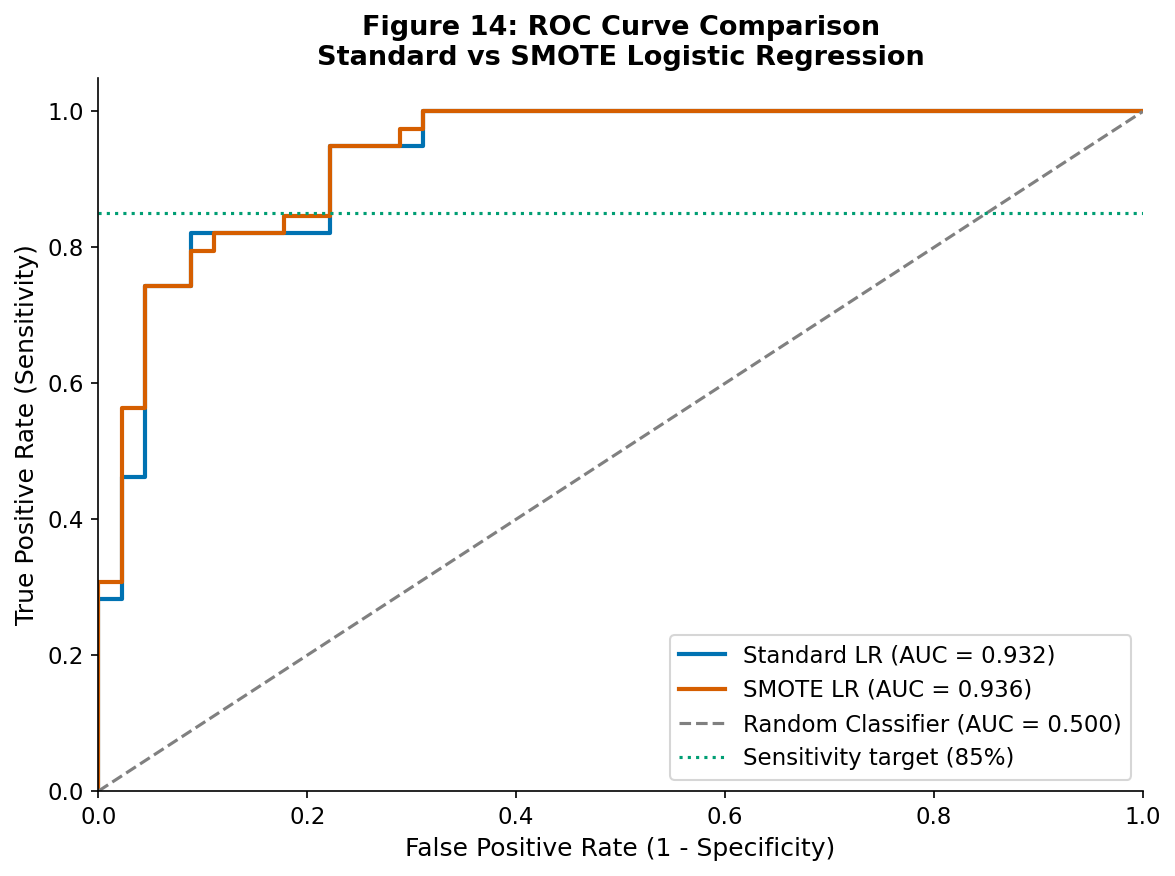

Figure 14 saved


In [24]:
# ROC - AUC Comparison
# LR Standard vs SMOTE

fpr_s, tpr_s, _ = roc_curve(y_test, y_pred_proba)
fpr_sm, tpr_sm, _ = roc_curve(y_test, y_pred_proba_smote)

auc_s = roc_auc_score(y_test, y_pred_proba)
auc_sm = roc_auc_score(y_test, y_pred_proba_smote)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_s, tpr_s, color='#0072B2', linewidth=2,
        label=f'Standard LR (AUC = {auc_s:.3f})')
ax.plot(fpr_sm, tpr_sm, color='#D55E00', linewidth=2,
        label=f'SMOTE LR (AUC = {auc_sm:.3f})')
ax.plot([0, 1], [0, 1], color='gray',
        linestyle='--', linewidth=1.5,
        label='Random Classifier (AUC = 0.500)')
ax.axhline(y=0.85, color='#009E73',
           linestyle=':', linewidth=1.5,
           label='Sensitivity target (85%)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Figure 14: ROC Curve Comparison\nStandard vs SMOTE Logistic Regression',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('figure14_roc_comparison.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 14 saved")

LR - Standard + CSL

In [25]:
# Create LR Standard + CSL Model

# L2 Regularization Default
# Address overfitting concerns

# Initialize model
# C=1.0 is default regularization strength

# Class Weight = Balanced

lr_csl = LogisticRegression(
    C=1.0,
    penalty='l2', # address overfitting on small dataset
    random_state=42,
    max_iter=1000,
    class_weight='balanced'  # CSL weight - penalizes false negatives more heavily
)

# Fit on training set
lr_csl.fit(X_train_encoded, y_train)

print("Logistic Regression model fitted successfully")
print(f"Number of features: {X_train_encoded.shape[1]}")
print(f"Classes: {lr_csl.classes_}")

Logistic Regression model fitted successfully
Number of features: 16
Classes: [0 1]


In [26]:
# Stratified K-Fold Cross Validation

skf_csl = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc'

}

# Run cross validation
cv_results_csl = cross_validate(
    lr_csl,
    X_train_encoded,
    y_train,
    cv=skf_csl,
    scoring=scoring,
    return_train_score=True  # returns train scores for overfitting check
)

# Print results
print("Logistic Regression CSL - Cross Validation Results (k=10)")
print(f"{'Metric':<20} {'Train Mean':>12} {'Test Mean':>12} {'Test Std':>10}")

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    train_mean = cv_results_csl[f'train_{metric}'].mean()
    test_mean = cv_results_csl[f'test_{metric}'].mean()
    test_std = cv_results_csl[f'test_{metric}'].std()
    print(f"{metric:<20} {train_mean:>12.3f} {test_mean:>12.3f} {test_std:>10.3f}")

print("\nNote: Recall = Sensitivity")
print("High train vs low test score indicates overfitting")

Logistic Regression CSL - Cross Validation Results (k=10)
Metric                 Train Mean    Test Mean   Test Std
accuracy                    0.846        0.793      0.078
precision                   0.847        0.790      0.073
recall                      0.812        0.754      0.166
f1                          0.829        0.763      0.104
roc_auc                     0.926        0.889      0.065

Note: Recall = Sensitivity
High train vs low test score indicates overfitting


In [27]:
# Test data

# Final evaluation using X_test_encoded
# Test set untouched during training and cross-validation


# Generate predictions
y_pred_csl = lr_csl.predict(X_test_encoded)
y_pred_proba_csl = lr_csl.predict_proba(X_test_encoded)[:, 1]

# Calculate all metrics
accuracy_csl = accuracy_score(y_test, y_pred_csl)
precision_csl = precision_score(y_test, y_pred_csl)
recall_csl = recall_score(y_test, y_pred_csl)
f1_csl = f1_score(y_test, y_pred_csl)
roc_auc_csl = roc_auc_score(y_test, y_pred_proba_csl)

# Confusion matrix
cm_csl = confusion_matrix(y_test, y_pred_csl)
tn_csl, fp_csl, fn_csl, tp_csl = cm_csl.ravel()

# Calculate specificity manually
specificity_csl = tn_csl / (tn_csl + fp_csl)

# Print results
print("Logistic Regression CSL - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_csl:.3f}")
print(f"Precision:   {precision_csl:.3f}")
print(f"Recall:      {recall_csl:.3f}  (Sensitivity)")
print(f"Specificity: {specificity_csl:.3f}")
print(f"F1:          {f1_csl:.3f}")
print(f"ROC-AUC:     {roc_auc_csl:.3f}")
print(f"\nConfusion Matrix:")
print(f"True Negatives:  {tn_csl}")
print(f"False Positives: {fp_csl}")
print(f"True Positives:  {tp_csl}")
print(f"False Negatives: {fn_csl}")
print(f"\nClinical interpretation:")
print(f"Missed CVD cases (FN): {fn_csl}")
print(f"False alarms (FP): {fp_csl}")

Logistic Regression CSL - Test Set Results
Accuracy:    0.857
Precision:   0.886
Recall:      0.795  (Sensitivity)
Specificity: 0.911
F1:          0.838
ROC-AUC:     0.933

Confusion Matrix:
True Negatives:  41
False Positives: 4
True Positives:  31
False Negatives: 8

Clinical interpretation:
Missed CVD cases (FN): 8
False alarms (FP): 4


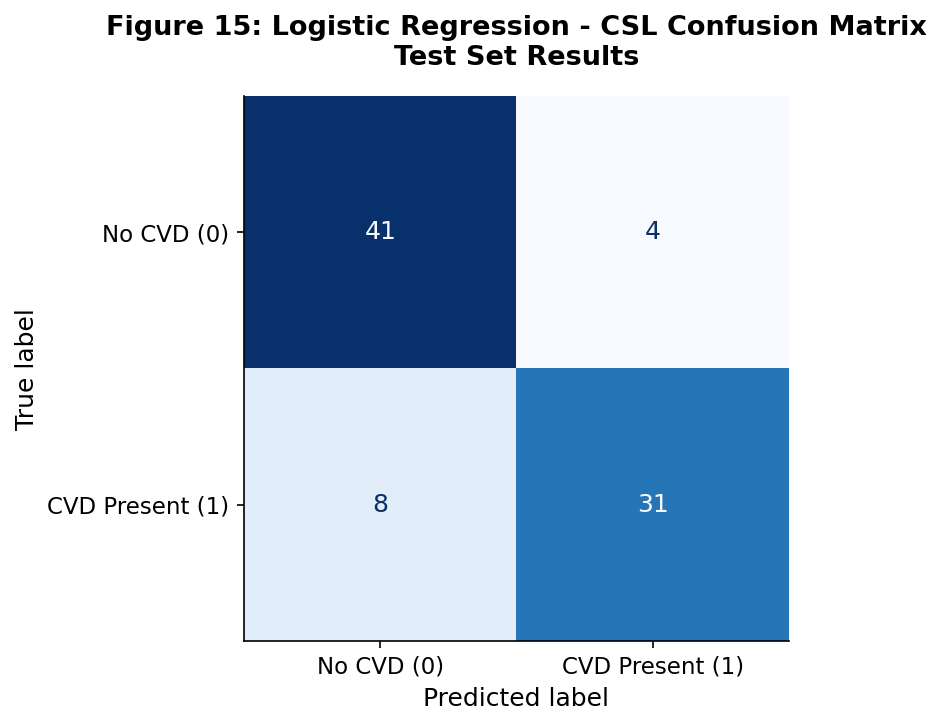

Figure 15 saved


In [28]:
# CSL Model - Confusion Matrix

fig, ax = plt.subplots(figsize=(7, 5))

# Display confusion matrix
disp_csl = ConfusionMatrixDisplay(
    confusion_matrix=cm_csl,
    display_labels=['No CVD (0)', 'CVD Present (1)']) #readability

disp_smote.plot(ax=ax, colorbar=False,
          cmap='Blues')

ax.set_title('Figure 15: Logistic Regression - CSL Confusion Matrix\nTest Set Results',
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('figure15_confusion_csl.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 15 saved")

LR - CSL + SMOTE


In [29]:
# LR Training Set - CSL + SMOTE

# Train model on SMOTE set
lr_csl_smote = LogisticRegression(
    C=1.0,
    penalty='l2',
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

# Fit on training set
lr_csl_smote.fit(X_train_smote, y_train_smote)

print("Logistic Regression - CSL + SMOTE model fitted successfully")
print(f"Number of features: {X_train_smote.shape[1]}")
print(f"Classes: {lr_csl_smote.classes_}")

Logistic Regression - CSL + SMOTE model fitted successfully
Number of features: 16
Classes: [0 1]


In [30]:
# Stratified k-fold CSL + SMOTE

# Define fresh StratifiedKFold for CSL + SMOTE set
skf_csl_smote = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',        # sensitivity
    'f1': 'f1',
    'roc_auc': 'roc_auc'
    }

# Run cross validation on SMOTE training set
cv_results_csl_smote = cross_validate(
    lr_csl_smote,
    X_train_smote,
    y_train_smote,
    cv=skf_csl_smote,
    scoring=scoring,
    return_train_score=True
)

# Print comparison
print("Cross Validation Comparison - SMOTE vs CSL + SMOTE")
print("=" * 65)
print(f"{'Metric':<20} {'Smt Train':>10} {'Smt Test':>10} {'CSL + SMOTE Train':>18} {'CSL + SMOTE Test':>18}")
print("-" * 65)

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
for metric in metrics:
    smt_train = cv_results_smote[f'train_{metric}'].mean()
    smt_test = cv_results_smote[f'test_{metric}'].mean()
    csl_smt_train = cv_results_csl_smote[f'train_{metric}'].mean()
    csl_smt_test = cv_results_csl_smote[f'test_{metric}'].mean()
    print(f"{metric:<20} {smt_train:>10.3f} {smt_test:>10.3f} {csl_smt_train:>12.3f} {csl_smt_test:>12.3f}")

print("\nNote: CV performed on respective training sets")
print("Overfitting check: compare train vs test within each model")

Cross Validation Comparison - SMOTE vs CSL + SMOTE
Metric                Smt Train   Smt Test  CSL + SMOTE Train   CSL + SMOTE Test
-----------------------------------------------------------------
accuracy                  0.863      0.848        0.863        0.848
precision                 0.886      0.874        0.885        0.874
recall                    0.834      0.827        0.835        0.827
f1                        0.859      0.846        0.859        0.846
roc_auc                   0.933      0.902        0.933        0.902

Note: CV performed on respective training sets
Overfitting check: compare train vs test within each model


In [32]:
# CSL + SMOTE Test Set evaluation

# Generate predictions on test set
y_pred_csl_smote = lr_csl_smote.predict(X_test_encoded)
y_pred_proba_csl_smote = lr_csl_smote.predict_proba(X_test_encoded)[:, 1]

# Confusion matrix
cm_csl_smote = confusion_matrix(y_test, y_pred_csl_smote)
tn_cs, fp_cs, fn_cs, tp_cs = cm_csl_smote.ravel()

# Calculate metrics
specificity_csl_smote = tn_cs / (tn_cs + fp_cs)

print("CSL + SMOTE Model - Test Set Results")
print("=" * 45)
print(f"Accuracy:    {accuracy_score(y_test, y_pred_csl_smote):.3f}")
print(f"Precision:   {precision_score(y_test, y_pred_csl_smote):.3f}")
print(f"Recall:      {recall_score(y_test, y_pred_csl_smote):.3f}  (Sensitivity)")
print(f"Specificity: {specificity_csl_smote:.3f}")
print(f"F1:          {f1_score(y_test, y_pred_csl_smote):.3f}")
print(f"ROC-AUC:     {roc_auc_score(y_test, y_pred_proba_csl_smote):.3f}")
print(f"\nFalse Negatives: {fn_cs}")
print(f"False Positives: {fp_cs}")

CSL + SMOTE Model - Test Set Results
Accuracy:    0.857
Precision:   0.886
Recall:      0.795  (Sensitivity)
Specificity: 0.911
F1:          0.838
ROC-AUC:     0.936

False Negatives: 8
False Positives: 4


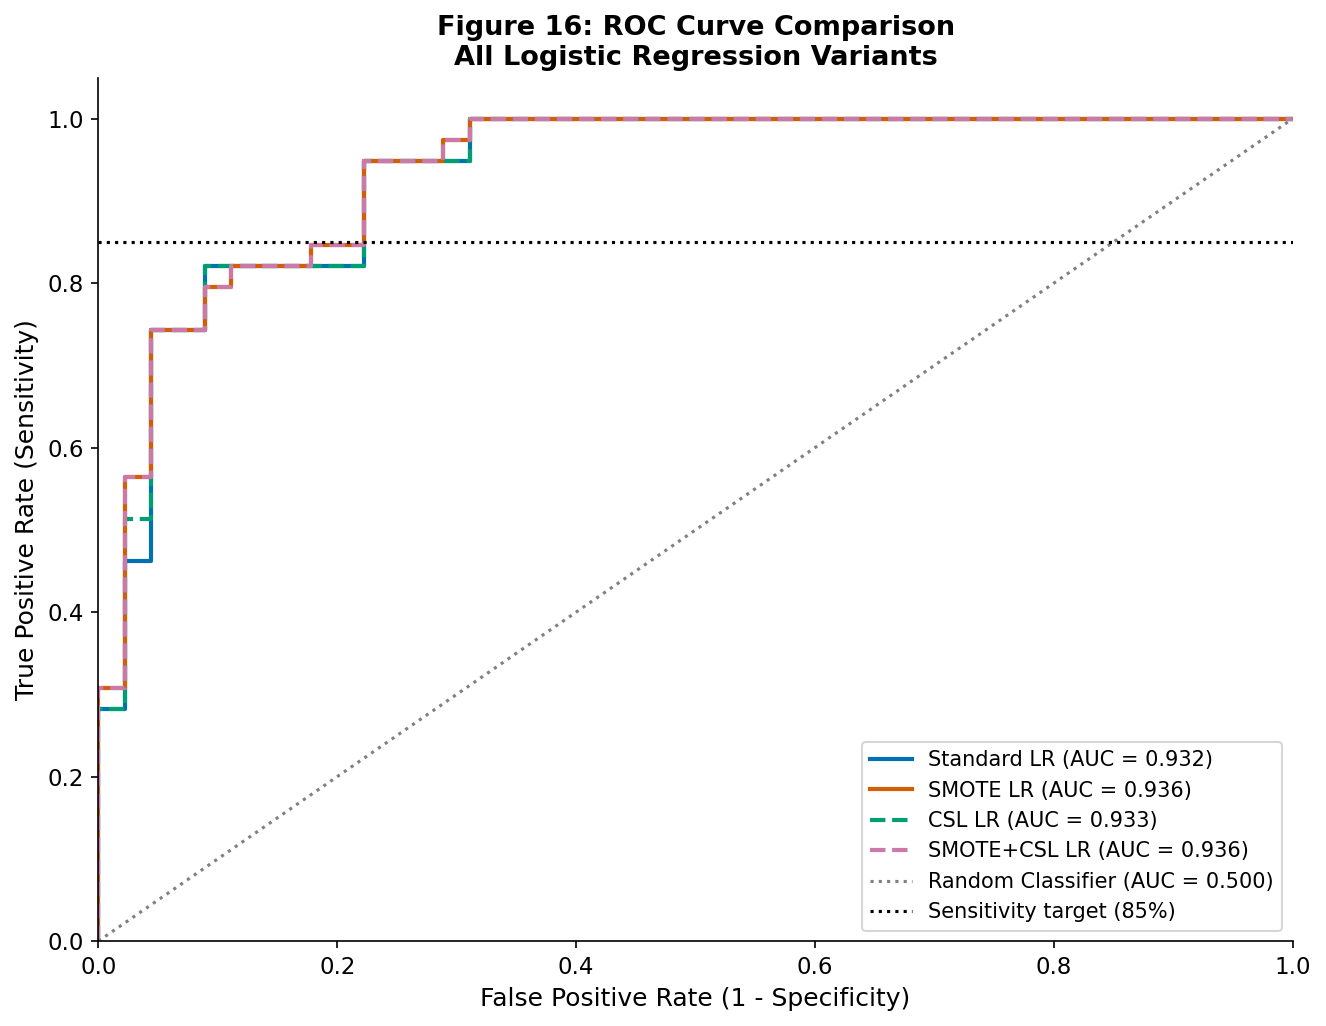

Figure 16 saved


In [33]:
# Final ROC Curve Comparison
# All Models

# Calculate ROC curves for all four models
fpr_std, tpr_std, _ = roc_curve(y_test, y_pred_proba)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_pred_proba_smote)
fpr_csl, tpr_csl, _ = roc_curve(y_test, y_pred_proba_csl)
fpr_cs, tpr_cs, _ = roc_curve(y_test, y_pred_proba_csl_smote)

# Calculate AUC for all four
auc_std = auc(fpr_std, tpr_std)
auc_smote = auc(fpr_smote, tpr_smote)
auc_csl = auc(fpr_csl, tpr_csl)
auc_cs = auc(fpr_cs, tpr_cs)

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(fpr_std, tpr_std, color='#0072B2',
        linewidth=2, label=f'Standard LR (AUC = {auc_std:.3f})')
ax.plot(fpr_smote, tpr_smote, color='#D55E00',
        linewidth=2, label=f'SMOTE LR (AUC = {auc_smote:.3f})')
ax.plot(fpr_csl, tpr_csl, color='#009E73',
        linewidth=2, linestyle='--',
        label=f'CSL LR (AUC = {auc_csl:.3f})')
ax.plot(fpr_cs, tpr_cs, color='#CC79A7',
        linewidth=2, linestyle='--',
        label=f'SMOTE+CSL LR (AUC = {auc_cs:.3f})')
ax.plot([0, 1], [0, 1], color='gray',
        linestyle=':', linewidth=1.5,
        label='Random Classifier (AUC = 0.500)')
ax.axhline(y=0.85, color='black',
           linestyle=':', linewidth=1.5,
           label='Sensitivity target (85%)')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Figure 16: ROC Curve Comparison\nAll Logistic Regression Variants',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('figure16_roc_all_lr_models.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Figure 16 saved")

Final Model Comparison

In [34]:
# Comparison Table of All Four Variants

# Recalculate all metrics from stored prediction arrays
models = {
    'Standard LR': (y_pred_proba, y_pred),
    'SMOTE LR': (y_pred_proba_smote, y_pred_smote),
    'CSL LR': (y_pred_proba_csl, y_pred_csl),
    'SMOTE+CSL LR': (y_pred_proba_csl_smote, y_pred_csl_smote)
}

results = []
for model_name, (proba, pred) in models.items():
    cm_temp = confusion_matrix(y_test, pred)
    tn_t, fp_t, fn_t, tp_t = cm_temp.ravel()

    results.append({
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_test, pred), 3),
        'Precision': round(precision_score(y_test, pred), 3),
        'Recall': round(recall_score(y_test, pred), 3),
        'Specificity': round(tn_t / (tn_t + fp_t), 3),
        'F1': round(f1_score(y_test, pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, proba), 3),
        'FN': fn_t,
        'FP': fp_t
    })

comparison_df = pd.DataFrame(results).set_index('Model')
print(comparison_df.to_string())

              Accuracy  Precision  Recall  Specificity     F1  ROC-AUC  FN  FP
Model                                                                         
Standard LR      0.833      0.879   0.744        0.911  0.806    0.932  10   4
SMOTE LR         0.857      0.886   0.795        0.911  0.838    0.936   8   4
CSL LR           0.857      0.886   0.795        0.911  0.838    0.933   8   4
SMOTE+CSL LR     0.857      0.886   0.795        0.911  0.838    0.936   8   4


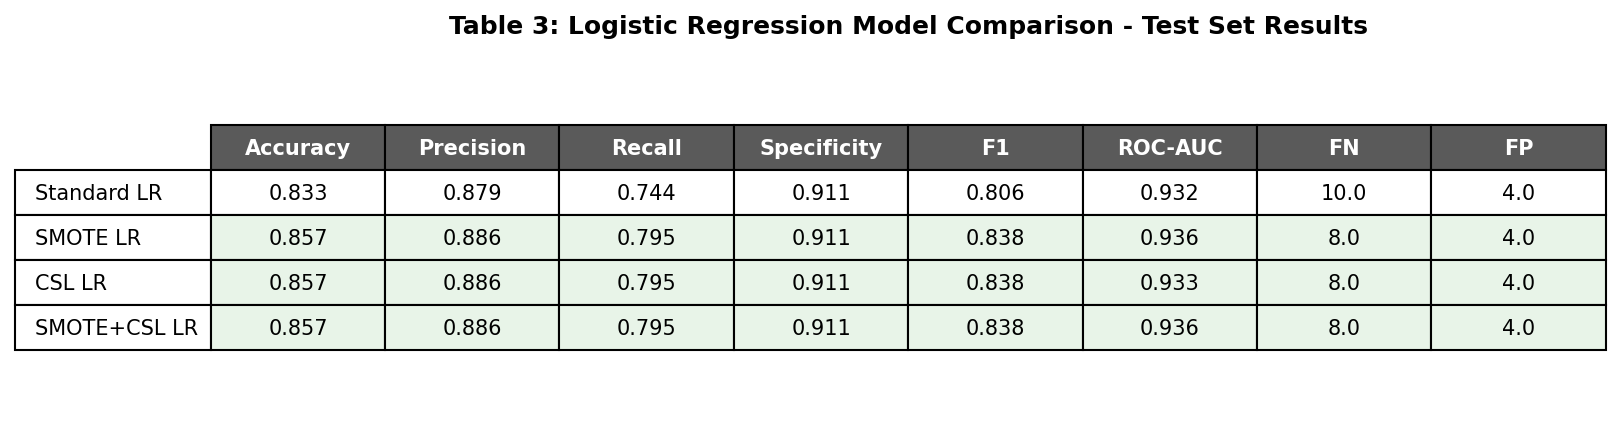

Table 3 saved


In [35]:
# Save Comparsion Table as Image

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')

comp_table = ax.table(
    cellText=comparison_df.values,
    rowLabels=comparison_df.index,
    colLabels=comparison_df.columns,
    loc='center',
    cellLoc='center'
)

comp_table.scale(1, 1.8)
comp_table.auto_set_font_size(False)
comp_table.set_fontsize(10)

# Style header
for j in range(len(comparison_df.columns)):
    comp_table[0, j].set_facecolor('#5a5a5a')
    comp_table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight best recall row
for j in range(len(comparison_df.columns)):
    for i in [2, 3, 4]:  # SMOTE, CSL, SMOTE+CSL rows
        comp_table[i, j].set_facecolor('#e8f4e8')

plt.title('Table 3: Logistic Regression Model Comparison - Test Set Results',
          fontsize=12, fontweight='bold', pad=15)
plt.savefig('table3_lr_comparison.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Table 3 saved")

In [36]:
# Verify Class Weights on SMOTE Set
# Confirms CSL is redundant when applied to balanced SMOTE data
# Equal weights of 1.0 prove no additional benefit


from sklearn.utils.class_weight import compute_class_weight


weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_smote)

print(f"Class weights on SMOTE set: {weights}")
print(f"\nInterpretation:")
print(f"Class 0 weight: {weights[0]:.3f}")
print(f"Class 1 weight: {weights[1]:.3f}")
if weights[0] == weights[1]:
    print("Equal weights confirm CSL adds no benefit on balanced SMOTE data")

Class weights on SMOTE set: [1. 1.]

Interpretation:
Class 0 weight: 1.000
Class 1 weight: 1.000
Equal weights confirm CSL adds no benefit on balanced SMOTE data


In [37]:
weights_original = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train)

print(f"\nClass weights on original training set:")
print(f"Class 0 weight: {weights_original[0]:.3f}")
print(f"Class 1 weight: {weights_original[1]:.3f}")
print(f"Difference: {abs(weights_original[0] - weights_original[1]):.3f}")


Class weights on original training set:
Class 0 weight: 0.926
Class 1 weight: 1.087
Difference: 0.161


Data Dictionary Update

In [38]:
# Data Dictionary

# Create Dataframe for data dictionary
data_dict_update2 = pd.DataFrame([
    ['age_binned', 'Categorical', 'Age group by categories to address BT violation', '0=Young (<45), 1=Middle (45-60), 2=Older (>60)'],
    ['sex', 'Categorical', 'Biological sex', '0 = Female, 1 = Male'],
    ['cp', 'Categorical', 'Chest pain type', '1 = Typical Angina, 2 = Atypical Angina, 3 = Non-Anginal Pain, 4 = Asymptomatic'],
    ['trestbps', 'Continuous', 'Resting blood pressure on admission (mmHg)', '94 - 200, note : standardized via StandardScaler during preprocessing'],
    ['chol_boxcox', 'Continuous', 'Box - Cox transformed cholesterol serum', 'standardized | Original range: 126-564 mg/dl, transformed and standardized via StandardScaler'],
    ['fbs', 'Categorical', 'Fasting blood sugar > 120 mg/dl', '0 = Normal, 1 = Elevated'],
    ['restecg', 'Categorical', 'Resting electrocardiographic results', '0 = Normal, 1 = ST-T Abnormality, 2 = LV Hypertrophy'],
    ['thalach', 'Continuous', 'Maximum heart rate achieved during exercise (bpm)', '71 - 202, note: standardized via StandardScaler during preprocessing'],
    ['exang', 'Categorical', 'Exercise induced angina', '0 = No, 1 = Yes'],
    ['st_severity', 'Categorical', 'ST depression and slope of peak exercise severity index', '0 = Normal, 1 = Equivocal, 2 = Positive, 3 = Strongly Positive'],
    ['ca', 'Categorical', 'Number of major vessels colored by fluoroscopy', '0 - 3'],
    ['thal', 'Categorical', 'Thalassemia type', '3 = Normal, 6 = Fixed Defect, 7 = Reversible Defect'],
    ['target', 'Binary Target', 'Cardiovascular disease diagnosis', '0 = No CVD, 1 = CVD Present']
],
columns=['Variable', 'Type', 'Description', 'Values/Range'])

# Make Values/Range column wrap
pd.set_option('display.max_colwidth', None)

# Hide the index and set column widths
dfi.export(data_dict_update2.style.hide(axis='index'),
           'data_dictionary2.png',
           table_conversion='matplotlib',
           max_rows=-1,
           max_cols=-1)
print("Data dictionary saved")

Data dictionary saved


Save Datasets and Models

In [41]:
# Save updated datasets
X_train_encoded.to_csv('/content/drive/MyDrive/X_train_encoded_w5.csv', index=False)
X_test_encoded.to_csv('/content/drive/MyDrive/X_test_encoded_w5.csv', index=False)
X_train_smote.to_csv('/content/drive/MyDrive/X_train_smote_w5.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/y_train_w5.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/y_test_w5.csv', index=False)
y_train_smote.to_csv('/content/drive/MyDrive/y_train_smote_w5.csv', index=False)

# Save fitted models
import joblib
joblib.dump(lr_model, '/content/drive/MyDrive/lr_standard_w5.pkl')
joblib.dump(lr_smote, '/content/drive/MyDrive/lr_smote_w5.pkl')
joblib.dump(lr_csl, '/content/drive/MyDrive/lr_csl_w5.pkl')
joblib.dump(lr_csl_smote, '/content/drive/MyDrive/lr_csl_smote_w5.pkl')

print("W5 datasets and models saved!")

W5 datasets and models saved!


In [40]:
print([col for col in X_train_encoded.columns if 'thal' in col])

['thalach', 'thal_6.0', 'thal_7.0']
